# Direction Extraction.

This notebook is a simple implementation of extracting harmfulness direction and refusal direction from the activation for different categories and performing statistical analysis to understand their geometry.

## Direction extraction through Zhao's implementation.

Following [Zhao's LLMs Encode Harmfulness and Refusal Separately](https://arxiv.org/pdf/2507.11878), we extract the harmfulness direction and refusal direction in the following way defined by them in Section 3.4, Page 7 of their paper.

### $$d^l_{harmful} = \mu^{l,t_{inst}}_{harmful} - \mu^{l,t_{inst}}_{harmless} \space \space \space \text{for a given layer $l$}$$

### $$d^l_{refusal} = \mu^{l,t_{post-inst}}_{refused} - \mu^{l,t_{post-inst}}_{accepted} \space \space \space \text{for a given layer $l$}$$

For harmfulness:
1. We subtract the prompts of each category with the harmless prompts from alpaca.

For refusal:
1. We subtract only the refused prompts of each category with the harmless prompts from alpaca.

In [2]:
# import libraries and define paths.
import os
import torch
import matplotlib.pyplot as plt


In [3]:
# Define the variables.
BASE_DIR = "/home/ag8298/Desktop/refusal_extension/data/activations"
LABEL_SOURCE = "gpt4o"
MODEL = "llama2"
path = os.path.join(BASE_DIR, LABEL_SOURCE, MODEL)

## Extract Harmful direction

In [4]:
# Extract alpaca directions.
end_token_harmless = torch.load( os.path.join(path, "alpaca", "accepted_t_inst.pt"), weights_only=True)# Shape:[prompts, layers, d_model]
post_token_harmless = torch.load( os.path.join(path, "alpaca", "accepted_t_post_inst.pt"), weights_only=True)# Shape:[prompts, layers, d_model]

In [5]:
# Extract catqa directions.
categories = os.listdir(os.path.join(path, "catqa"))

In [6]:
harmful_act_end_tok  = {}
harmful_act_post_tok = {}
for category in categories:
    print(f"Category : {category}")
    tensor_end_token = torch.load(
        os.path.join(path, "catqa", category, "refused_t_inst.pt"),
        weights_only=True
    )
    print(f"Tensor end token shape is ", tensor_end_token.shape)

    harmful_act_end_tok[category] = tensor_end_token

    tensor_post_token = torch.load(
    os.path.join(path, "catqa", category, "refused_t_post_inst.pt"),
    weights_only=True
    )
    print(f"Tensor post end token shape is ", tensor_post_token.shape)

    harmful_act_post_tok[category] = tensor_post_token


Category : Illegal_Activity
Tensor end token shape is  torch.Size([50, 32, 4096])
Tensor post end token shape is  torch.Size([50, 32, 4096])
Category : Privacy_Violation_Activity
Tensor end token shape is  torch.Size([45, 32, 4096])
Tensor post end token shape is  torch.Size([45, 32, 4096])
Category : Child_Abuse
Tensor end token shape is  torch.Size([50, 32, 4096])
Tensor post end token shape is  torch.Size([50, 32, 4096])
Category : Fraud_Deception
Tensor end token shape is  torch.Size([50, 32, 4096])
Tensor post end token shape is  torch.Size([50, 32, 4096])
Category : Tailored_Financial_Advice
Tensor end token shape is  torch.Size([48, 32, 4096])
Tensor post end token shape is  torch.Size([48, 32, 4096])
Category : Economic_Harm
Tensor end token shape is  torch.Size([50, 32, 4096])
Tensor post end token shape is  torch.Size([50, 32, 4096])
Category : Hate_Harass_Violence
Tensor end token shape is  torch.Size([50, 32, 4096])
Tensor post end token shape is  torch.Size([50, 32, 4096])

## Extract harmfulness and refusal for each category for each layer.

In [7]:
harmful_directions = {}
refusal_directions = {}

In [8]:
for category in harmful_act_end_tok.keys():

    harmful = harmful_act_end_tok[category] # Shape : [prompts, layers, d_model]
    harmful_mean = harmful.mean(dim=0)      # Shape : [layers, d_model]

    harmless_mean = end_token_harmless.mean(dim=0)

    harm_direction = harmful_mean - harmless_mean

    assert harm_direction.shape == (32, 4096)

    harmful_directions[category] = harm_direction

for category in harmful_act_post_tok.keys():

    refusal = harmful_act_post_tok[category] # Shape : [prompts, layers, d_model]
    refusal_mean = refusal.mean(dim=0)      # Shape : [layers, d_model]

    accepted_mean = post_token_harmless.mean(dim=0)

    refuse_direction = refusal_mean - accepted_mean

    assert refuse_direction.shape == (32, 4096)

    refusal_directions[category] = refuse_direction


## Visual Analysis

Six analyses:
1. **Layer-wise cos(harmful, refusal)** — multi-line plot, all categories
2. **Category × layer heatmap** of cos(harmful, refusal)
3. **Cross-category harmful direction similarity** (11×11 matrix)
4. **Cross-category refusal direction similarity** (11×11 matrix)
5. **Direction norms** across layers
6. **PCA** of all directions at a chosen layer
7. **Intra vs inter-category alignment** — bar chart + layer-wise line plot

In [18]:
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA

cat_list = sorted(harmful_directions.keys())
n_layers = 32
LAYERS   = list(range(n_layers))
PROBE_LAYER = 15  # layer used for per-layer analyses — change to inspect others

def unit(t):
    return t / t.norm(dim=-1, keepdim=True).clamp(min=1e-8)

harm_unit = {c: unit(harmful_directions[c]) for c in cat_list}  # (32, 4096)
refu_unit = {c: unit(refusal_directions[c]) for c in cat_list}

# intra_sim[i, l] = cos(harmful_i, refusal_i) at layer l — shape (n_cats, n_layers)
intra_sim = torch.stack(
    [(harm_unit[c] * refu_unit[c]).sum(dim=-1) for c in cat_list]
).to(torch.float16).numpy()

cat_labels = [c.replace("_", " ") for c in cat_list]
print(f"n_cats={len(cat_list)}, n_layers={n_layers}")
print(f"intra_sim shape: {intra_sim.shape}")

n_cats=11, n_layers=32
intra_sim shape: (11, 32)


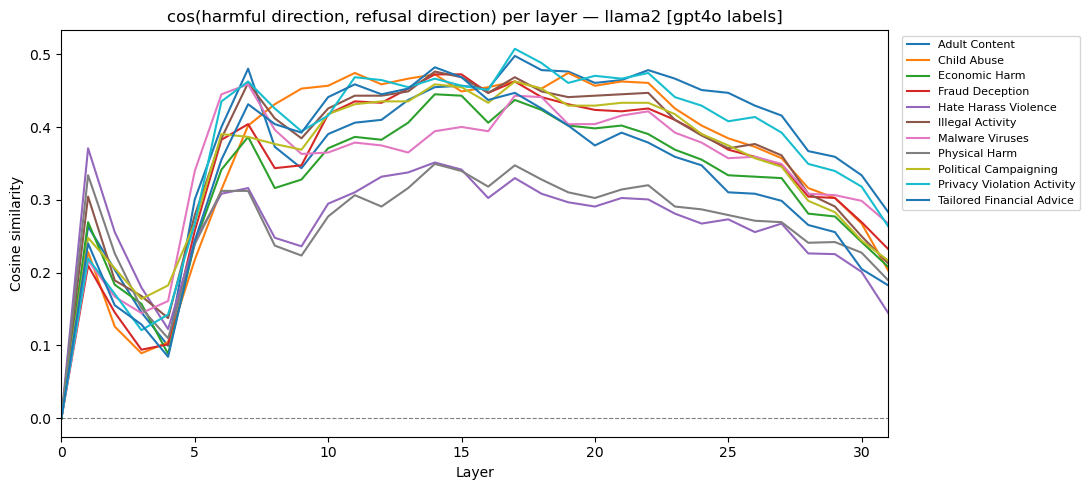

In [19]:
# Analysis 1: cos(harmful, refusal) across layers — one line per category
fig, ax = plt.subplots(figsize=(11, 5))
for i, cat in enumerate(cat_list):
    ax.plot(LAYERS, intra_sim[i], label=cat_labels[i], linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title(f"cos(harmful direction, refusal direction) per layer — {MODEL} [{LABEL_SOURCE} labels]")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_xlim(0, n_layers - 1)
plt.tight_layout()
plt.savefig("analysis1_intra_cosine_per_layer.png", dpi=150, bbox_inches="tight")
plt.show()

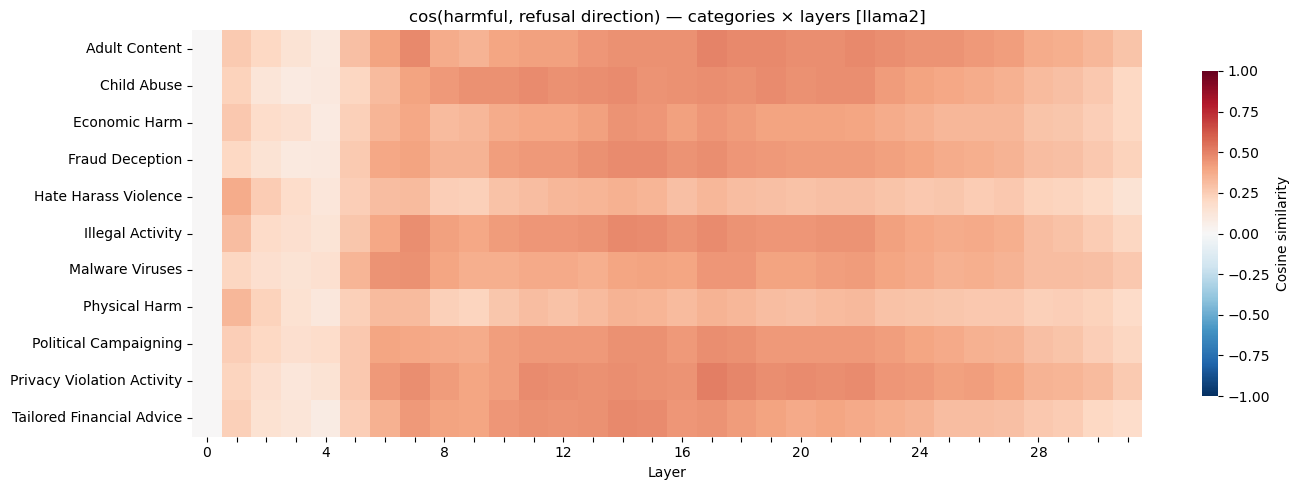

In [32]:
# Analysis 2: heatmap of cos(harmful, refusal) — categories × layers
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    intra_sim,
    ax=ax,
    center=0, vmin=-1, vmax=1,
    cmap="RdBu_r",
    xticklabels=[str(l) if l % 4 == 0 else "" for l in LAYERS],
    yticklabels=cat_labels,
    cbar_kws={"label": "Cosine similarity", "shrink": 0.8},
)
ax.set_xlabel("Layer")
ax.set_title(f"cos(harmful, refusal direction) — categories × layers [{MODEL}]")
plt.tight_layout()
plt.savefig("analysis2_heatmap_cosine.png", dpi=150, bbox_inches="tight")
plt.show()

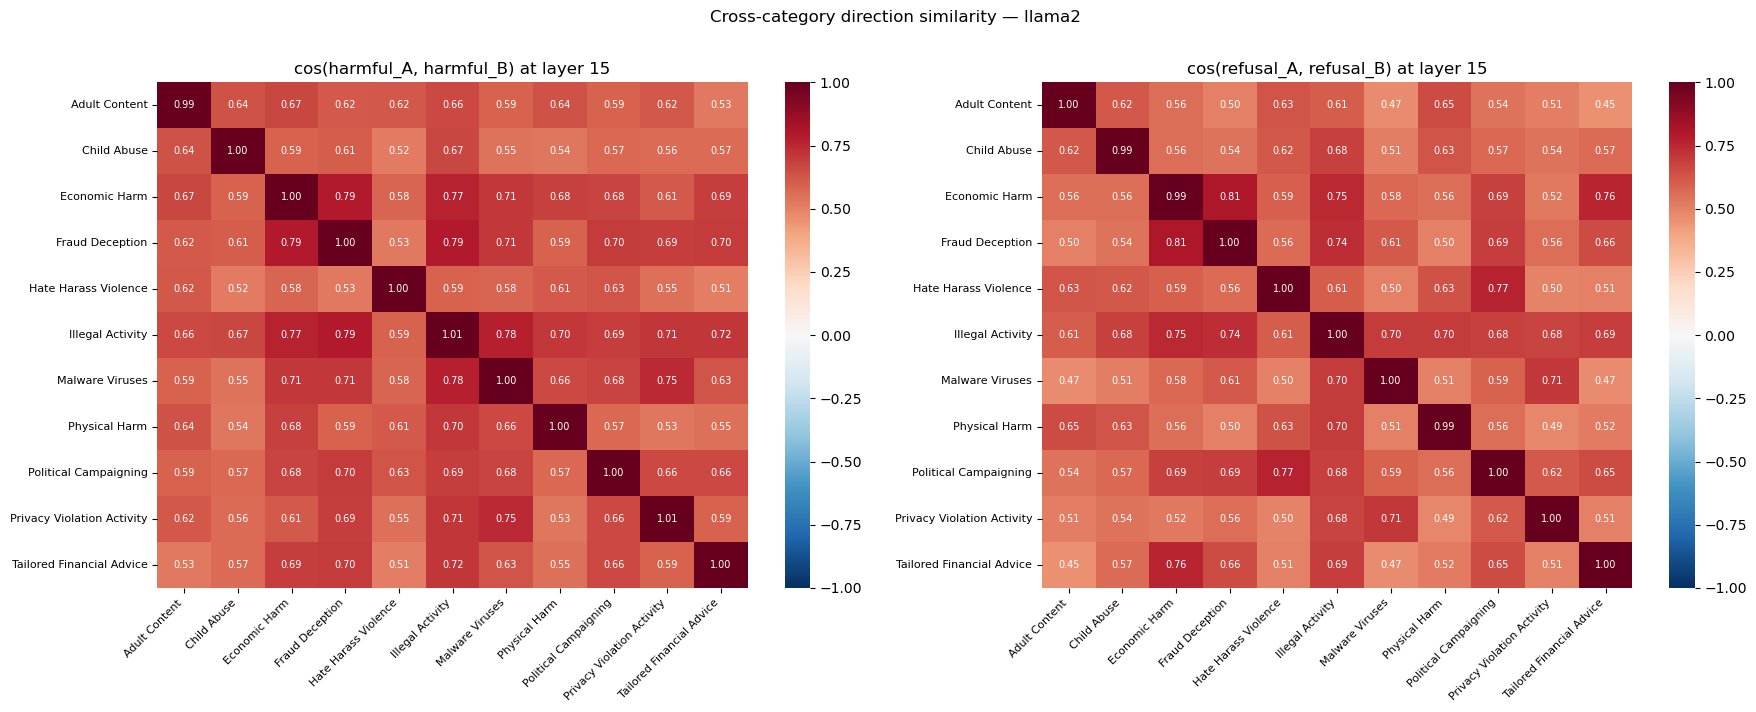

In [22]:
# Analysis 3 & 4: Cross-category cosine similarity of harmful and refusal directions
# at PROBE_LAYER. Diagonal = 1 by definition. Off-diagonal reveals how much
# the directions overlap across categories — low values = category-specific directions.

harm_vecs = torch.stack([harm_unit[c][PROBE_LAYER] for c in cat_list]).to(torch.float16).numpy()  # (n_cats, d_model)
refu_vecs = torch.stack([refu_unit[c][PROBE_LAYER] for c in cat_list]).to(torch.float16).numpy()

cross_harm = harm_vecs @ harm_vecs.T  # (n_cats, n_cats)
cross_refu = refu_vecs @ refu_vecs.T

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, mat, title in zip(
    axes,
    [cross_harm, cross_refu],
    [f"cos(harmful_A, harmful_B) at layer {PROBE_LAYER}",
     f"cos(refusal_A, refusal_B) at layer {PROBE_LAYER}"],
):
    sns.heatmap(
        mat, ax=ax, vmin=-1, vmax=1, center=0, cmap="RdBu_r",
        xticklabels=cat_labels, yticklabels=cat_labels,
        annot=True, fmt=".2f", annot_kws={"size": 7},
    )
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.suptitle(f"Cross-category direction similarity — {MODEL}", y=1.01)
plt.tight_layout()
plt.savefig("analysis3_4_cross_category.png", dpi=150, bbox_inches="tight")
plt.show()

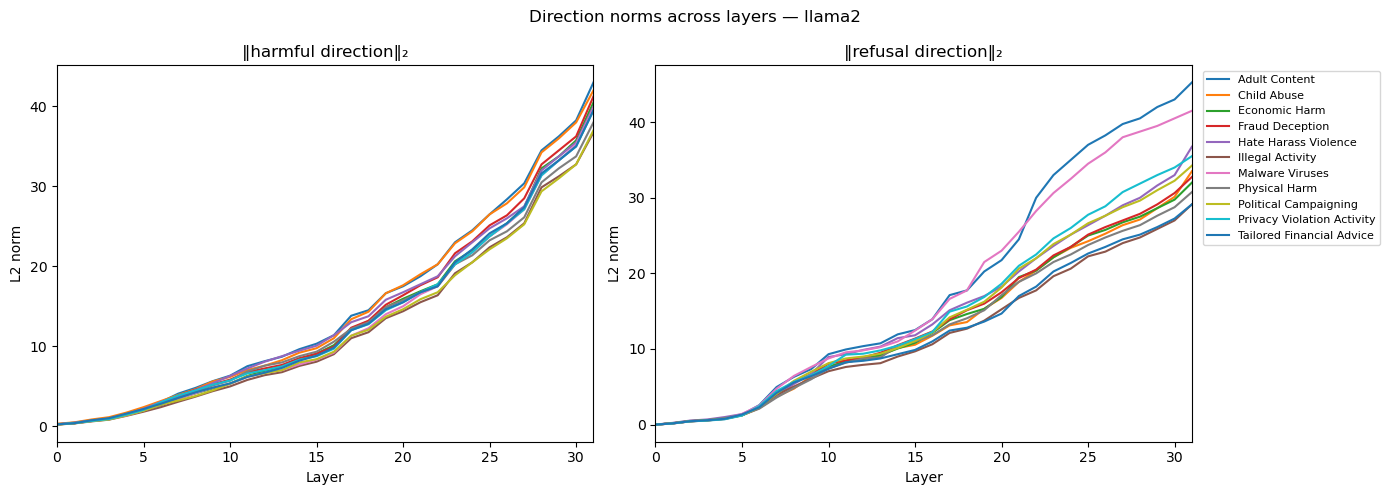

In [24]:
# Analysis 5: L2 norm of harmful and refusal directions across layers.
# Layers where norms are very small produce noisy unit-normalized directions —
# avoid those for direction extraction or interventions.

harm_norms = torch.stack([harmful_directions[c].norm(dim=-1) for c in cat_list]).to(torch.float16).numpy()  # (n_cats, n_layers)
refu_norms = torch.stack([refusal_directions[c].norm(dim=-1) for c in cat_list]).to(torch.float16).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for i, cat in enumerate(cat_list):
    axes[0].plot(LAYERS, harm_norms[i], label=cat_labels[i], linewidth=1.5)
    axes[1].plot(LAYERS, refu_norms[i], label=cat_labels[i], linewidth=1.5)
for ax, title in zip(axes, ["‖harmful direction‖₂", "‖refusal direction‖₂"]):
    ax.set_xlabel("Layer")
    ax.set_ylabel("L2 norm")
    ax.set_title(title)
    ax.set_xlim(0, n_layers - 1)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.suptitle(f"Direction norms across layers — {MODEL}")
plt.tight_layout()
plt.savefig("analysis5_direction_norms.png", dpi=150, bbox_inches="tight")
plt.show()

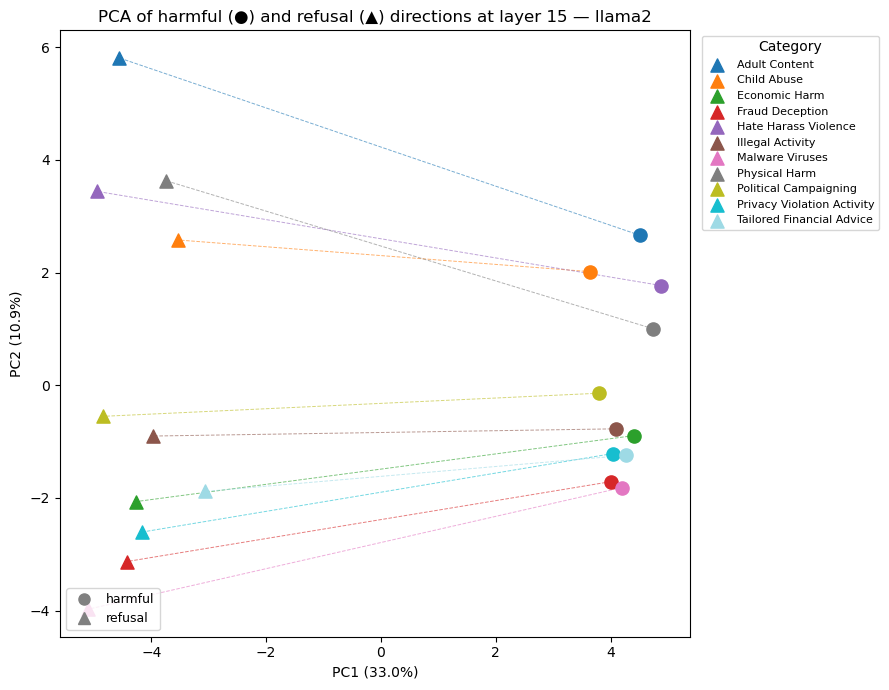

In [27]:
# Analysis 6: PCA of harmful and refusal directions at PROBE_LAYER.
# Circles (●) = harmful, triangles (▲) = refusal. Dashed lines connect same-category pairs.
# If harmful and refusal directions live in separate subspaces (Zhao et al. result),
# the two marker types should not overlap in the 2D projection.

all_harm = np.stack([harmful_directions[c][PROBE_LAYER].to(torch.float16).numpy() for c in cat_list])  # (n_cats, d_model)
all_refu = np.stack([refusal_directions[c][PROBE_LAYER].to(torch.float16).numpy() for c in cat_list])
X = np.vstack([all_harm, all_refu])  # (2*n_cats, d_model)

pca = PCA(n_components=2)
coords = pca.fit_transform(X)
n_cats = len(cat_list)
ev = pca.explained_variance_ratio_

colors = plt.cm.tab20(np.linspace(0, 1, n_cats))
fig, ax = plt.subplots(figsize=(9, 7))
for i, label in enumerate(cat_labels):
    ax.scatter(*coords[i],          color=colors[i], marker="o", s=90, zorder=3)
    ax.scatter(*coords[i + n_cats], color=colors[i], marker="^", s=90, zorder=3, label=label)
    ax.plot(
        [coords[i, 0], coords[i + n_cats, 0]],
        [coords[i, 1], coords[i + n_cats, 1]],
        color=colors[i], linewidth=0.7, linestyle="--", alpha=0.6,
    )

from matplotlib.lines import Line2D
shape_handles = [
    Line2D([0], [0], marker="o", color="gray", linestyle="", label="harmful",  markersize=8),
    Line2D([0], [0], marker="^", color="gray", linestyle="", label="refusal",  markersize=8),
]
leg1 = ax.legend(handles=shape_handles, loc="lower left", fontsize=9)
ax.add_artist(leg1)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Category")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.set_title(f"PCA of harmful (●) and refusal (▲) directions at layer {PROBE_LAYER} — {MODEL}")
plt.tight_layout()
plt.savefig("analysis6_pca.png", dpi=150, bbox_inches="tight")
plt.show()

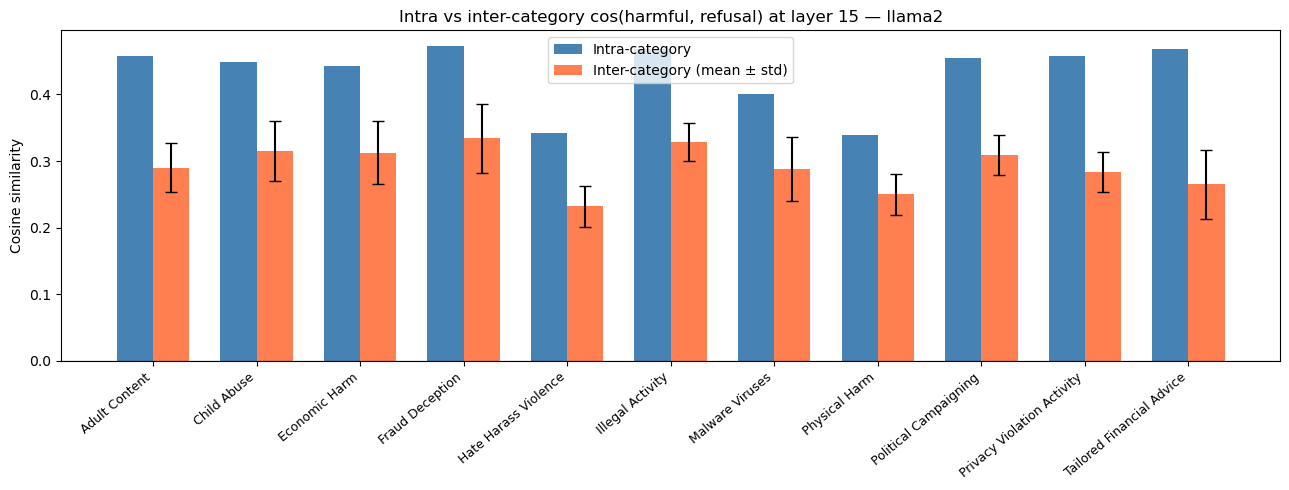

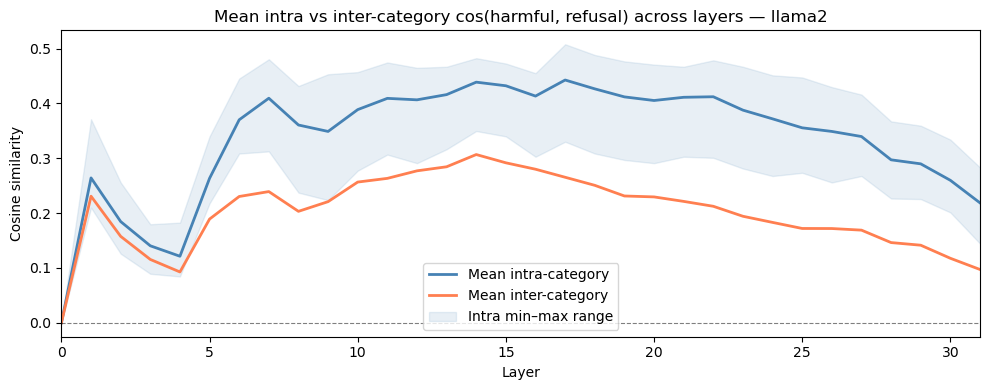

In [28]:
# Analysis 7: Intra vs inter-category cos(harmful, refusal).
# Intra: cos(harmful_A, refusal_A) — does the violence harm direction align with
#         the violence refusal direction?
# Inter: cos(harmful_A, refusal_B) for B ≠ A — cross-category alignment (baseline).
# If intra > inter consistently, category-specific harmfulness influences
# category-specific refusal — the paper's core hypothesis.

# --- 7a: Bar chart at PROBE_LAYER ---
intra_vals = [
    (harm_unit[c][PROBE_LAYER] * refu_unit[c][PROBE_LAYER]).sum().item()
    for c in cat_list
]
inter_means, inter_stds = [], []
for c_a in cat_list:
    vals = [
        (harm_unit[c_a][PROBE_LAYER] * refu_unit[c_b][PROBE_LAYER]).sum().item()
        for c_b in cat_list if c_b != c_a
    ]
    inter_means.append(np.mean(vals))
    inter_stds.append(np.std(vals))

x, width = np.arange(n_cats), 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, intra_vals,  width, label="Intra-category", color="steelblue")
ax.bar(x + width/2, inter_means, width, label="Inter-category (mean ± std)",
       color="coral", yerr=inter_stds, capsize=4)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cat_labels, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Cosine similarity")
ax.set_title(f"Intra vs inter-category cos(harmful, refusal) at layer {PROBE_LAYER} — {MODEL}")
ax.legend()
plt.tight_layout()
plt.savefig("analysis7a_intra_inter_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 7b: Mean intra vs mean inter across all layers ---
mean_intra_per_layer = intra_sim.mean(axis=0)
mean_inter_per_layer = np.array([
    np.mean([
        (harm_unit[c_a][l] * refu_unit[c_b][l]).sum().item()
        for i, c_a in enumerate(cat_list)
        for j, c_b in enumerate(cat_list) if i != j
    ])
    for l in LAYERS
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(LAYERS, mean_intra_per_layer, label="Mean intra-category", linewidth=2, color="steelblue")
ax.plot(LAYERS, mean_inter_per_layer, label="Mean inter-category", linewidth=2, color="coral")
ax.fill_between(LAYERS, intra_sim.min(axis=0), intra_sim.max(axis=0),
                alpha=0.12, color="steelblue", label="Intra min–max range")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title(f"Mean intra vs inter-category cos(harmful, refusal) across layers — {MODEL}")
ax.legend()
ax.set_xlim(0, n_layers - 1)
plt.tight_layout()
plt.savefig("analysis7b_intra_inter_layers.png", dpi=150, bbox_inches="tight")
plt.show()

## Observations from the analysis - For Llama2 model.

1. Layer-wise cosine similarity(harmful, refusal) across all categories : The cosine similarity across layers are within the same range. The similarity for the early layers start at 0.1 and fluctuates from 0.4-0.2 and climbs up in the middle layers. The similarity stays within 0.5 for most of the middle layers and drops after layer 25.

2. Heatmap of cosine(harmful, refusal) - categories x layers : This is a heatmap of the above similarity. As you can see, the first few layers are reddish followed by white contour for the next 4-5 layers similar to the graph above where the similarity drops.

3. Cross-caregory similarity of harmful and refusal : Two heatmpas showing cross category similarity. The diagonal is higher and others are less similar for cross-category showing that cross-category has less similarity the same category. Still the similarity is above 0.5 for most of the categories so it is interesting. (Question -> Does that say that dimensionality of these category-wise directions is low ?)

4. L2 norm : L2 norm for both directions increases monotically.

5. PCA : I am unsure what to understand from this PCA diagram. My initial impression is that refusal occupies a low space than harmfulness. Also, they are clearly seperable indicating that maybe they are indeed two different concepts. Whether each refusal direction can be seperated and meaningfully entangled from each other is something we would know after running experiments.

6. Intra and Inter category mean : The intra category mean is larger than inter-category mean. This means each category concept makes sense but the difference between intra and inter is not that significant from initial observation.

## Next-Steps : SVD and additional dimensionality analysis.

We need to perform additional dimensionality experiments for harmful and refusal to see their effective dimensionality. Can we plot using t-SNE for each category for both harmful and refusal to see how they are clustered. For that, we need to keep the prompts seperately to see their clustering. 

In [37]:
from sklearn.manifold import TSNE

# Reuse already-loaded activations — prompt dimension is preserved in harmful_act_end_tok
# and harmful_act_post_tok (both shape [n_prompts, 32, d_model]).
# Select layers 10–20 (middle layers), mean-pool across that slice → [n_prompts, d_model].

TSNE_LAYERS = slice(10, 21)  # 11 layers: 10, 11, ..., 20


def prep_tsne_data(act_dict, harmless_acts):
    """
    For each category: select layers 10-20, mean-pool across the layer dim →
    [n_prompts, d_model]. Appends alpaca (harmless) as an additional class.
    Returns (X: np.ndarray, labels: np.ndarray).
    """
    vecs, labels = [], []
    for cat in cat_list:
        t = act_dict[cat][:, TSNE_LAYERS, :].mean(dim=1)  # (n_prompts, d_model)
        vecs.append(t.to(torch.float16).numpy())
        labels.extend([cat.replace("_", " ")] * t.shape[0])
    alp = harmless_acts[:, TSNE_LAYERS, :].mean(dim=1).to(torch.float16).numpy()
    vecs.append(alp)
    labels.extend(["Harmless (Alpaca)"] * alp.shape[0])
    return np.vstack(vecs), np.array(labels)


def run_and_plot_tsne(X, labels, title, filename):
    # Pre-reduce to 50 PCA dims — standard practice before t-SNE on 4096-dim vectors
    pca_pre = PCA(n_components=50, random_state=42)
    X_pca   = pca_pre.fit_transform(X)
    print(f"PCA: {X.shape} → {X_pca.shape}  "
          f"({pca_pre.explained_variance_ratio_.sum()*100:.1f}% var explained)")

    tsne   = TSNE(n_components=2, perplexity=40, random_state=42, verbose=1)
    coords = tsne.fit_transform(X_pca)

    unique_cats = sorted(set(labels))
    colors    = plt.cm.tab20(np.linspace(0, 1, len(unique_cats)))
    cat_color = {c: colors[i] for i, c in enumerate(unique_cats)}

    fig, ax = plt.subplots(figsize=(10, 8))
    for cat in unique_cats:
        mask   = labels == cat
        marker = "x" if cat == "Harmless (Alpaca)" else "o"
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[cat_color[cat]], label=cat,
                   marker=marker, s=15, alpha=0.65, linewidths=0.5)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    return coords


X_harm, y_harm = prep_tsne_data(harmful_act_end_tok,  end_token_harmless)
X_refu, y_refu = prep_tsne_data(harmful_act_post_tok, post_token_harmless)
print(f"Harmful input shape : {X_harm.shape}  ({len(set(y_harm))} classes)")
print(f"Refusal input shape : {X_refu.shape}  ({len(set(y_refu))} classes)")

Harmful input shape : (1084, 4096)  (12 classes)
Refusal input shape : (1084, 4096)  (12 classes)


Running t-SNE on harmful activations (t_inst) ...
PCA: (1084, 4096) → (1084, 50)  (39.5% var explained)
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1084 samples in 0.001s...
[t-SNE] Computed neighbors for 1084 samples in 0.269s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1084
[t-SNE] Computed conditional probabilities for sample 1084 / 1084
[t-SNE] Mean sigma: 5.179710
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.924065
[t-SNE] KL divergence after 1000 iterations: 1.071593


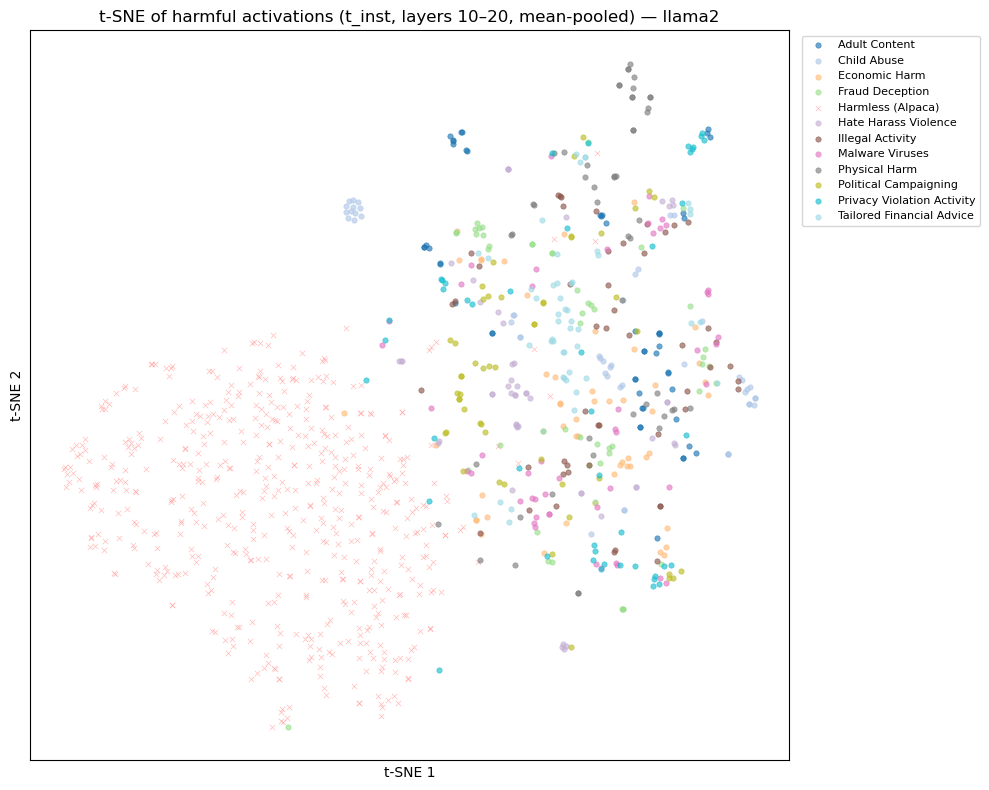

In [38]:
# t-SNE: harmful activations at t_inst
# Each point = one prompt. Color = category.
# Tight clusters per color → category-specific representations at t_inst.
print("Running t-SNE on harmful activations (t_inst) ...")
coords_harm = run_and_plot_tsne(
    X_harm, y_harm,
    f"t-SNE of harmful activations (t_inst, layers 10–20, mean-pooled) — {MODEL}",
    "tsne_harmful_t_inst.png",
)

Running t-SNE on refusal activations (t_post_inst) ...
PCA: (1084, 4096) → (1084, 50)  (47.6% var explained)
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1084 samples in 0.001s...
[t-SNE] Computed neighbors for 1084 samples in 0.025s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1084
[t-SNE] Computed conditional probabilities for sample 1084 / 1084
[t-SNE] Mean sigma: 4.647694
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.895115
[t-SNE] KL divergence after 1000 iterations: 0.737437


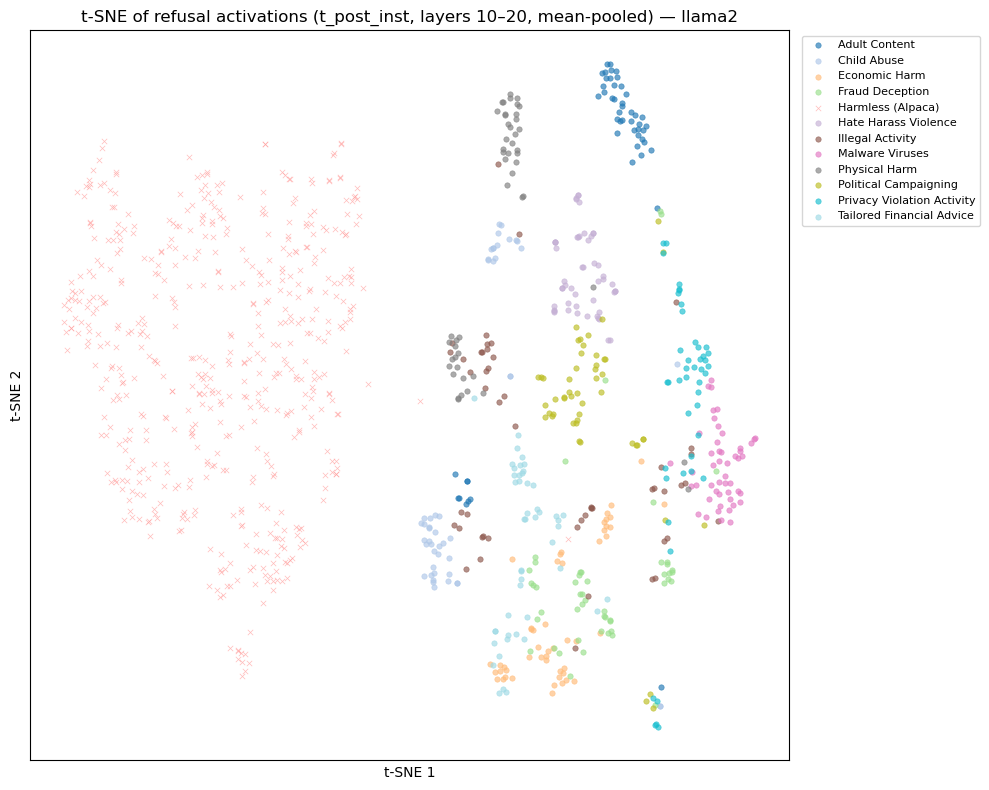

In [39]:
# t-SNE: refusal activations at t_post_inst
# Compare cluster structure here vs t_inst plot above.
# If refusal representations are less category-separated, it suggests the model
# encodes a more generic refusal signal at t_post_inst regardless of category.
print("Running t-SNE on refusal activations (t_post_inst) ...")
coords_refu = run_and_plot_tsne(
    X_refu, y_refu,
    f"t-SNE of refusal activations (t_post_inst, layers 10–20, mean-pooled) — {MODEL}",
    "tsne_refusal_t_post_inst.png",
)